# Sales & Profitability Analysis — Global Superstore
## Exploratory Data Analysis (EDA)

**Question:** Which product categories, regions, and discount levels are actually driving profit — and which ones are quietly losing money?

Dataset: Global Superstore (Kaggle)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")
df.shape

(9994, 21)

## 1. First look

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Duplicate rows
dupes = df.duplicated(subset=[c for c in df.columns if c != "Row ID"])
print(f"Duplicate rows: {dupes.sum()}")

Duplicate rows: 1


In [7]:
# Negative profit — this is your real veracity story now
neg_profit = df[df["Profit"] < 0]
print(f"Negative-profit orders: {len(neg_profit)} ({len(neg_profit)/len(df):.1%})")
neg_profit[["Category", "Sub-Category", "Discount", "Sales", "Profit"]].head(10)

Negative-profit orders: 1871 (18.7%)


,Category,Sub-Category,Discount,Sales,Profit
3,Furniture,Tables,0.45,957.5775,-383.0310
14,Office Supplies,Appliances,0.80,68.8100,-123.8580
15,Office Supplies,Binders,0.80,2.5440,-3.8160
23,Furniture,Chairs,0.30,71.3720,-1.0196
27,Furniture,Bookcases,0.50,3083.4300,-1665.0522
28,Office Supplies,Binders,0.70,9.6180,-7.0532
32,Office Supplies,Binders,0.70,6.8580,-5.7150
36,Furniture,Furnishings,0.60,190.9200,-147.9630
38,Furniture,Bookcases,0.32,532.3992,-46.9764
39,Furniture,Chairs,0.30,212.0580,-15.1470


In [8]:
# Sanity check dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
bad_dates = df[df["Ship Date"] < df["Order Date"]]
print(f"Rows where Ship Date < Order Date: {len(bad_dates)}")

Rows where Ship Date < Order Date: 0


## 2. Data quality checks — judgment calls

In [9]:
dupes = df.duplicated(subset=[c for c in df.columns if c != "Row ID"])
print(f"Duplicate rows: {dupes.sum()}")
df[dupes]

Duplicate rows: 1


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3406,3407,US-2014-150119,2014-04-23,2014-04-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


**Judgment call 1 — duplicates:** 1 exact duplicate row found. This is almost certainly a data export artifact rather than a real repeated order line. Dropping it, keeping the first occurrence.

**Judgment call 2 — negative profit:** 1,871 orders (18.7% of all orders) are net loss-making. This is a large enough share that it isn't noise — it's a real pattern worth investigating, not an error to clean away. These rows are kept in for every downstream step, since discovering *where* these losses concentrate (category, discount level, region) is the actual point of this analysis.

In [10]:
# What's driving the 18.7% loss rate? Quick look at discount level among loss-making orders
neg_profit["Discount"].value_counts().sort_index()

Discount
0.10      4
0.15     17
0.20    502
0.30    208
0.32     27
0.40    180
0.45     11
0.50     66
0.60    138
0.70    418
0.80    300
Name: count, dtype: int64

In [11]:
# Loss rate by discount tier (normalized, not just raw counts)
loss_rate = df.groupby("Discount").apply(
    lambda x: (x["Profit"] < 0).mean()
)
loss_rate.sort_index()

Discount
0.00    0.000000
0.10    0.042553
0.15    0.326923
0.20    0.137271
0.30    0.916300
0.32    1.000000
0.40    0.873786
0.45    1.000000
0.50    1.000000
0.60    1.000000
0.70    1.000000
0.80    1.000000
dtype: float64

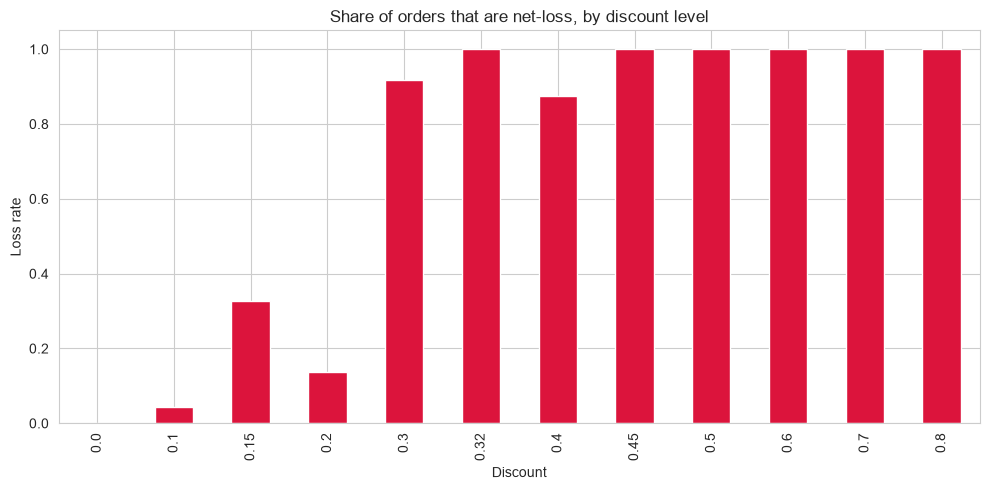

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
loss_rate.sort_index().plot(kind="bar", ax=ax, color="crimson")
ax.set_title("Share of orders that are net-loss, by discount level")
ax.set_ylabel("Loss rate")
ax.set_xlabel("Discount")
plt.tight_layout()
plt.show()

## 3. Key finding — the discount threshold

Loss rate by discount level shows a sharp, non-gradual tipping point:

| Discount | Loss rate |
|---|---|
| 0% | 0% |
| 10–20% | 4–33% |
| 30%+ | 87–100% |

Below 20% discount, most orders still turn a profit. At 30% discount and above, **nearly every order loses money** — this isn't a gradual erosion, it's a cliff edge. This is the single most actionable finding in the dataset: discounting above ~25% is very likely a straightforward path to loss, almost regardless of category.

In [13]:
# Does the 30%+ cliff hold across all categories, or is it concentrated somewhere?
high_discount = df[df["Discount"] >= 0.3]
high_discount.groupby("Category")["Profit"].agg(
    loss_rate=lambda x: (x < 0).mean(),
    order_count="count"
)

,loss_rate,order_count
Category,,
Furniture,0.972325,542
Office Supplies,1.000000,680
Technology,0.824561,171


The 30%+ discount cliff holds across every category, not just one:

| Category | Loss rate at 30%+ discount | Orders |
|---|---|---|
| Office Supplies | 100.0% | 680 |
| Furniture | 97.2% | 542 |
| Technology | 82.5% | 171 |

Office Supplies is the most severe — literally every high-discount order loses money — while Technology is comparatively more resilient, though still losing money on the large majority of heavily discounted orders. This rules out "it's just a Furniture problem" and supports a company-wide policy change rather than a category-specific one.